In [22]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import networkx as nx
import random

from tqdm import tqdm
pd.set_option('display.max_columns', 5000)

In [5]:
def format_ml(df_crime, df_lamps):
    """
    Transforms a wide-format crime dataset into a long format with lag features for ML.
    Now correctly merges static street lighting data and prevents double-smoothing.
    """
    # Merge static lighting data onto the crime network
    df = pd.merge(df_crime, df_lamps[['edge_id', 'lamp_count', 'lamp_per_km', 'is_lit']], on='edge_id', how='left')
    
    # 1. Isolate static features (Added osmid, is_lit, and lamp_per_km)
    static_features = [
        'edge_id', 'osmid', 'u', 'u_lat', 'u_lng', 'v', 'v_lat', 'v_lng', 
        'key', 'name', 'highway', 'length', 'is_lit', 'lamp_per_km'
    ]
    df_static = df[static_features].copy()

    # 2. Isolating time series
    # The regex will now automatically pick up the new _netkde_YYYY_MM columns
    time_cols = [col for col in df.columns if pd.Series(col).str.contains(r'\d{4}_\d{2}$').any()]
    df_time = df[['edge_id'] + time_cols].copy()

    # 3. Condensing all time columns into 'metric' and 'value'
    df_melted = df_time.melt(id_vars='edge_id', var_name='metric_month', value_name='value')

    # 4. Split the melted column into a 'metric' and a 'year_month'
    extract_regex = r'^(?P<metric>.*)_(?P<year_month>\d{4}_\d{2})$'
    df_melted[['metric', 'year_month']] = df_melted['metric_month'].str.extract(extract_regex)
    df_melted = df_melted.drop(columns=['metric_month'])

    # 5. Pivot: Push the metrics back into their own distinct columns
    df_long = df_melted.pivot(
        index=['edge_id', 'year_month'], 
        columns='metric', 
        values='value'
    ).reset_index()

    # 6. Sort chronologically
    df_long = df_long.sort_values(by=['edge_id', 'year_month'])

    # 7. Engineer Lag Features (2, 3, and 4 months to account for API delay)
    lags = [2, 3, 4]
    metrics_to_lag = ['crime_perceived_risk_sum_netkde', 'stop_search_count_netkde']

    for metric in metrics_to_lag:
        for lag in lags:
            df_long[f'{metric}_lag_{lag}'] = df_long.groupby('edge_id')[metric].shift(lag)

    # 8. Drop rows with NaNs caused by the shift
    df_long = df_long.dropna(subset=[f'{metric}_lag_{lag}' for metric in metrics_to_lag for lag in lags]).reset_index(drop=True)

    # 9. Merge the static street metadata back in
    final_df = pd.merge(df_long, df_static, on='edge_id', how='left')

    # 10. Rename current month metrics to 'target'
    final_df = final_df.rename(columns={
        'crime_perceived_risk_sum_netkde': 'target_perceived_risk',
        'stop_search_count_netkde': 'target_stop_search'
    })
    
    # 11. NetKDE double-smoothing logic removed entirely.
    
    return final_df

In [6]:
def train_crime_model(ml_ready_df):
    """
    Trains the XGBoost ML model to predict NetKDE Perceived Risk
    """
    # 1. Define the chronological cutoff
    cutoff_month = '2026_03'
    
    # 2. Split into Train (Past) and Test (Future)
    train_df = ml_ready_df[ml_ready_df['year_month'] < cutoff_month].copy()
    test_df = ml_ready_df[ml_ready_df['year_month'] >= cutoff_month].copy()
    
    print(f"Training on {len(train_df)} records (Before {cutoff_month})")
    print(f"Testing on {len(test_df)} records ({cutoff_month} onwards)")

    # 3. Define the Target (y)
    target_col = 'target_perceived_risk'
    
    # 4. Define Features (X)
    # Dropping osmid alongside identifiers to prevent ML from learning raw IDs
    cols_to_drop = [
        'edge_id', 'osmid', 'year_month', 'name', 'u', 'v', 'key', 
        'target_perceived_risk', 'target_stop_search',
        'crime_count_netkde', 'crime_severity_sum_netkde', 
        'crime_perceived_risk_sum' , 'crime_severity_sum', 'crime_count', 'stop_search_count'
    ]
    
    train_df['highway'] = train_df['highway'].astype('category')
    test_df['highway'] = test_df['highway'].astype('category')
    
    X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
    y_train = train_df[target_col]
    
    X_test = test_df.drop(columns=cols_to_drop, errors='ignore')
    y_test = test_df[target_col]

    # 5. Initialize XGBoost Regressor
    # Objective changed to reg:squarederror because the target is a continuous float
    model = xgb.XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        enable_categorical=True,
        random_state=42,
        early_stopping_rounds=50,
        objective='reg:squarederror'
    )

    # 6. Train the model
    print("Training XGBoost...")
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=50
    )

    # 7. Evaluate the predictions
    predictions = model.predict(X_test)
    mae = mean_absolute_error(y_test, predictions)
    print(f"\nMean Absolute Error (MAE): {mae:.2f} perceived risk score per street")
    
    return model, X_train.columns

In [7]:
def feature_importance(model, X_train):
    """
    Extracts feature importance and displays in a bar chart.
    """
    # 1. Visual Plot: Using XGBoost's built-in plotter
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # We use importance_type='gain' because it measures predictive power
    xgb.plot_importance(
        model, 
        importance_type='gain', 
        max_num_features=15, # Only show the top 15 features
        ax=ax, 
        height=0.5,
        color='steelblue'
    )
    plt.title("Top 15 Most Predictive Features (by Information Gain)")
    plt.show()

    # 2. Raw Data: Extracting into a Pandas DataFrame
    importance_dict = model.get_booster().get_score(importance_type='gain')
    
    importance_df = pd.DataFrame({
        'Feature': list(importance_dict.keys()),
        'Gain': list(importance_dict.values())
    })
    
    # Sort from most to least important
    importance_df = importance_df.sort_values(by='Gain', ascending=False).reset_index(drop=True)
    
    print("\nFeature Importance Rankings:")
    print(importance_df.head(15))
    
    return importance_df

In [8]:
def predict_and_map_to_nodes(ml_ready_df, model, feature_columns, month_t_minus_2, month_t_minus_3, month_t_minus_4):
    """
    Maps historical targets directly into future lags, predicts danger, and prepares OSM node/edge costs.
    """
    if isinstance(feature_columns, pd.DataFrame):
        feature_columns = feature_columns.columns.tolist()
    elif hasattr(feature_columns, 'tolist'):
        feature_columns = feature_columns.tolist()
    
    # 1. Isolate the base metadata from the most recent month to serve as our template
    future_data = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_2].copy()
    
    # 2. Extract historical targets to use as future lags
    data_t2 = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_2].set_index('edge_id')
    data_t3 = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_3].set_index('edge_id')
    data_t4 = ml_ready_df[ml_ready_df['year_month'] == month_t_minus_4].set_index('edge_id')
    
    # 3. Map the true historical values directly into the required lags
    future_data['crime_perceived_risk_sum_netkde_lag_2'] = future_data['edge_id'].map(data_t2['target_perceived_risk']).fillna(0)
    future_data['crime_perceived_risk_sum_netkde_lag_3'] = future_data['edge_id'].map(data_t3['target_perceived_risk']).fillna(0)
    future_data['crime_perceived_risk_sum_netkde_lag_4'] = future_data['edge_id'].map(data_t4['target_perceived_risk']).fillna(0)
    
    future_data['stop_search_count_netkde_lag_2'] = future_data['edge_id'].map(data_t2['target_stop_search']).fillna(0)
    future_data['stop_search_count_netkde_lag_3'] = future_data['edge_id'].map(data_t3['target_stop_search']).fillna(0)
    future_data['stop_search_count_netkde_lag_4'] = future_data['edge_id'].map(data_t4['target_stop_search']).fillna(0)
    
    if 'highway' in future_data.columns:
        future_data['highway'] = future_data['highway'].astype('category')
    
    X_future = future_data[feature_columns]

    # 4. Generate Predictions
    print("Predicting future safety scores...")
    future_data['predicted_risk'] = model.predict(X_future)
    future_data['predicted_risk'] = future_data['predicted_risk'].clip(lower=0)

    # 5. Calculate "Safety Cost" (1-10 Scale)
    future_data['log_risk'] = np.log1p(future_data['predicted_risk'])
    max_risk = future_data['log_risk'].max()
    min_risk = future_data['log_risk'].min()
    
    if max_risk == min_risk:
        print("Warning: The model predicted flat values. Cost is flat.")
        future_data['safety_tag_value'] = 1.0
    else:
        # Scale to exactly 1-10 (multiply by 9, add 1)
        future_data['safety_tag_value'] = 1 + ((future_data['log_risk'] - min_risk) / (max_risk - min_risk) * 9)

    # 6. Map Edge Costs onto OSM Nodes
    u_nodes = future_data[['u', 'u_lat', 'u_lng', 'safety_tag_value']].rename(
        columns={'u': 'node_id', 'u_lat': 'lat', 'u_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    v_nodes = future_data[['v', 'v_lat', 'v_lng', 'safety_tag_value']].rename(
        columns={'v': 'node_id', 'v_lat': 'lat', 'v_lng': 'lng', 'safety_tag_value': 'cost'}
    )
    
    all_nodes = pd.concat([u_nodes, v_nodes])
    node_safety_df = all_nodes.groupby('node_id').agg(
        node_safety_cost=('cost', 'mean'),
        lat=('lat', 'first'),
        lng=('lng', 'first')
    ).reset_index()

    node_safety_df = node_safety_df.sort_values(by='node_safety_cost', ascending=False).reset_index(drop=True)
    return future_data, node_safety_df


def osm_tag_mapping(future_edges_df):
    """
    Creates a clean mapping of OSM Way IDs to Safety Costs and Lighting status.
    """
    df = future_edges_df.copy()
    df['safety_tag_value'] = df['safety_tag_value'].round().astype(int)
    
    # Isolate osmid (instead of edge_id) and pass the is_lit flag for dynamic routing
    osm_tags = df[['osmid', 'safety_tag_value', 'is_lit']].drop_duplicates()
    
    osm_tags.to_csv('osm_safety_tags.csv', index=False)
    print("Saved OSM Tag mapping. Use this to tag your .osm.pbf file.")

In [9]:
def osm_tag_mapping(future_edges_df):
    """
    Creates a clean mapping of OSM Way IDs to Safety Costs.
    """
    df = future_edges_df.copy()
    
    # We round the safety cost to an integer (1-10) to make the Valhalla Lua costing easier
    df['safety_tag_value'] = df['safety_tag_value'].round().astype(int)
    
    # Isolate just the OSM ID and the new Tag Value
    osm_tags = df[['edge_id', 'safety_tag_value']].drop_duplicates()
    
    osm_tags.to_csv('osm_safety_tags.csv', index=False)
    print("Saved OSM Tag mapping. Use this to tag your .osm.pbf file.")

In [20]:
def evaluate_routing_performance(edges_df, num_simulations=1000):
    """
    Evaluates the ML safety routing engine against standard Dijkstra shortest path.
    
    Expected edge_df columns:
    - u, v: OSM node IDs
    - length: Physical length of the street in metres
    - safety_tag_value: The 1-10 scaled ML prediction used for routing
    - target_perceived_risk: The true NetKDE float used to measure actual risk
    """
    print(f"Building evaluation graph...")
    
    # Create the graph for routing simulation
    G = nx.Graph()
    for _, row in edges_df.iterrows():
        # The routing engine optimizes for physical length * safety penalty
        edge_routing_weight = row['length'] * row['safety_tag_value']
        
        G.add_edge(
            row['u'], 
            row['v'], 
            length=row['length'], 
            routing_weight=edge_routing_weight,
            true_risk=row['target_perceived_risk'] * row['length'] # Total risk exposure
        )

    nodes = list(G.nodes())
    results = []
    
    print(f"Running {num_simulations} simulated Origin-Destination pairs...")
    
    for _ in tqdm(range(num_simulations), desc="Simulating Routes"):
        # Pick a random start and end node
        origin, destination = random.sample(nodes, 2)
        
        try:
            # 1. Standard Routing: Optimize purely for distance
            shortest_path = nx.shortest_path(G, origin, destination, weight='length')
            
            # 2. ML Routing: Optimize for safety-weighted distance
            safest_path = nx.shortest_path(G, origin, destination, weight='routing_weight')
            
            # Helper function to calculate total metrics for a given path
            def calculate_path_metrics(path):
                total_distance = 0.0
                total_risk = 0.0
                for i in range(len(path) - 1):
                    u, v = path[i], path[i+1]
                    edge_data = G[u][v]
                    total_distance += edge_data['length']
                    total_risk += edge_data['true_risk']
                return total_distance, total_risk

            dist_shortest, risk_shortest = calculate_path_metrics(shortest_path)
            dist_safest, risk_safest = calculate_path_metrics(safest_path)
            
            # If the routes are identical, skip to avoid division-by-zero in trade-off stats
            if dist_shortest == dist_safest:
                continue
                
            # Calculate Professor's Requested Metrics
            pct_risk_reduction = ((risk_shortest - risk_safest) / risk_shortest) * 100 if risk_shortest > 0 else 0
            pct_distance_increase = ((dist_safest - dist_shortest) / dist_shortest) * 100 if dist_shortest > 0 else 0
            
            # Safety Improvement Efficiency: Units of risk avoided per extra metre run
            sie = (risk_shortest - risk_safest) / (dist_safest - dist_shortest)
            
            results.append({
                'dist_shortest': dist_shortest,
                'dist_safest': dist_safest,
                'risk_shortest': risk_shortest,
                'risk_safest': risk_safest,
                'pct_risk_reduction': pct_risk_reduction,
                'pct_distance_increase': pct_distance_increase,
                'sie': sie
            })
            
        except nx.NetworkXNoPath:
            # Skip if the random nodes are in disconnected subgraphs
            continue

    # Aggregate and print final evaluation
    results_df = pd.DataFrame(results)
    
    print("\n=== Route Evaluation Results ===")
    print(f"Total valid divergent routes simulated: {len(results_df)}")
    print(f"Average Distance Increase: {results_df['pct_distance_increase'].mean():.2f}%")
    print(f"Average Risk Reduction: {results_df['pct_risk_reduction'].mean():.2f}%")
    print(f"Average Safety Improvement Efficiency (SIE): {results_df['sie'].mean():.4f} risk units/metre")
    
    return results_df

In [11]:
df_crime = pd.read_csv('data_out/edge_features.csv')
df_lamps = pd.read_csv('data_out/edge_lamp_features.csv')

df_ml = format_ml(df_crime, df_lamps)

In [13]:
df_crime.head()

,edge_id,osmid,u,u_lat,u_lng,v,v_lat,v_lng,key,name,highway,length,crime_count,crime_severity_sum,crime_perceived_risk_sum,stop_search_count,crime_count_2023_06,crime_count_2023_07,crime_count_2023_08,crime_count_2023_09,crime_count_2023_10,crime_count_2023_11,crime_count_2023_12,crime_count_2024_01,crime_count_2024_02,crime_count_2024_03,crime_count_2024_04,crime_count_2024_05,crime_count_2024_06,crime_count_2024_07,crime_count_2024_08,crime_count_2024_09,crime_count_2024_10,crime_count_2024_11,crime_count_2024_12,crime_count_2025_01,crime_count_2025_02,crime_count_2025_03,crime_count_2025_04,crime_count_2025_05,crime_count_2025_06,crime_count_2025_07,crime_count_2025_08,crime_count_2025_09,crime_count_2025_10,crime_count_2025_11,crime_count_2025_12,crime_count_2026_01,crime_count_2026_02,crime_count_2026_03,crime_count_2026_04,crime_count_2026_05,crime_severity_sum_2023_06,crime_severity_sum_2023_07,crime_severity_sum_2023_08,crime_severity_sum_2023_09,crime_severity_sum_2023_10,crime_severity_sum_2023_11,crime_severity_sum_2023_12,crime_severity_sum_2024_01,crime_severity_sum_2024_02,crime_severity_sum_2024_03,crime_severity_sum_2024_04,crime_severity_sum_2024_05,crime_severity_sum_2024_06,crime_severity_sum_2024_07,crime_severity_sum_2024_08,crime_severity_sum_2024_09,crime_severity_sum_2024_10,crime_severity_sum_2024_11,crime_severity_sum_2024_12,crime_severity_sum_2025_01,crime_severity_sum_2025_02,crime_severity_sum_2025_03,crime_severity_sum_2025_04,crime_severity_sum_2025_05,crime_severity_sum_2025_06,crime_severity_sum_2025_07,crime_severity_sum_2025_08,crime_severity_sum_2025_09,crime_severity_sum_2025_10,crime_severity_sum_2025_11,crime_severity_sum_2025_12,crime_severity_sum_2026_01,crime_severity_sum_2026_02,crime_severity_sum_2026_03,crime_severity_sum_2026_04,crime_severity_sum_2026_05,crime_perceived_risk_sum_2023_06,crime_perceived_risk_sum_2023_07,crime_perceived_risk_sum_2023_08,crime_perceived_risk_sum_2023_09,crime_perceived_risk_sum_2023_10,crime_perceived_risk_sum_2023_11,crime_perceived_risk_sum_2023_12,crime_perceived_risk_sum_2024_01,crime_perceived_risk_sum_2024_02,crime_perceived_risk_sum_2024_03,crime_perceived_risk_sum_2024_04,crime_perceived_risk_sum_2024_05,crime_perceived_risk_sum_2024_06,crime_perceived_risk_sum_2024_07,crime_perceived_risk_sum_2024_08,crime_perceived_risk_sum_2024_09,crime_perceived_risk_sum_2024_10,crime_perceived_risk_sum_2024_11,crime_perceived_risk_sum_2024_12,crime_perceived_risk_sum_2025_01,crime_perceived_risk_sum_2025_02,crime_perceived_risk_sum_2025_03,crime_perceived_risk_sum_2025_04,crime_perceived_risk_sum_2025_05,crime_perceived_risk_sum_2025_06,crime_perceived_risk_sum_2025_07,crime_perceived_risk_sum_2025_08,crime_perceived_risk_sum_2025_09,crime_perceived_risk_sum_2025_10,crime_perceived_risk_sum_2025_11,crime_perceived_risk_sum_2025_12,crime_perceived_risk_sum_2026_01,crime_perceived_risk_sum_2026_02,crime_perceived_risk_sum_2026_03,crime_perceived_risk_sum_2026_04,crime_perceived_risk_sum_2026_05,stop_search_count_2023_06,stop_search_count_2023_07,stop_search_count_2023_08,stop_search_count_2023_09,stop_search_count_2023_10,stop_search_count_2023_11,stop_search_count_2023_12,stop_search_count_2024_01,stop_search_count_2024_02,stop_search_count_2024_03,stop_search_count_2024_04,stop_search_count_2024_05,stop_search_count_2024_06,stop_search_count_2024_07,stop_search_count_2024_08,stop_search_count_2024_09,stop_search_count_2024_10,stop_search_count_2024_11,stop_search_count_2024_12,stop_search_count_2025_01,stop_search_count_2025_02,stop_search_count_2025_03,stop_search_count_2025_04,stop_search_count_2025_05,stop_search_count_2025_06,stop_search_count_2025_07,stop_search_count_2025_08,stop_search_count_2025_09,stop_search_count_2025_10,stop_search_count_2025_11,stop_search_count_2025_12,stop_search_count_2026_01,stop_search_count_2026_02,stop_search_count_2026_03,stop_search_count_2026_04,stop_search_count_2026_05,crime_per_km,crime_severity_per_km,crime_av

In [14]:
model, X_train = train_crime_model(df_ml)

Training on 1030428 records (Before 2026_03)
Testing on 106596 records (2026_03 onwards)
Training XGBoost...
[0]	validation_0-rmse:17.88074	validation_1-rmse:15.89488
[50]	validation_0-rmse:7.36276	validation_1-rmse:7.22858
[100]	validation_0-rmse:6.93299	validation_1-rmse:7.02525
[150]	validation_0-rmse:6.74360	validation_1-rmse:7.02914
[200]	validation_0-rmse:6.59205	validation_1-rmse:6.99738
[246]	validation_0-rmse:6.46345	validation_1-rmse:7.01631

Mean Absolute Error (MAE): 2.46 perceived risk score per street


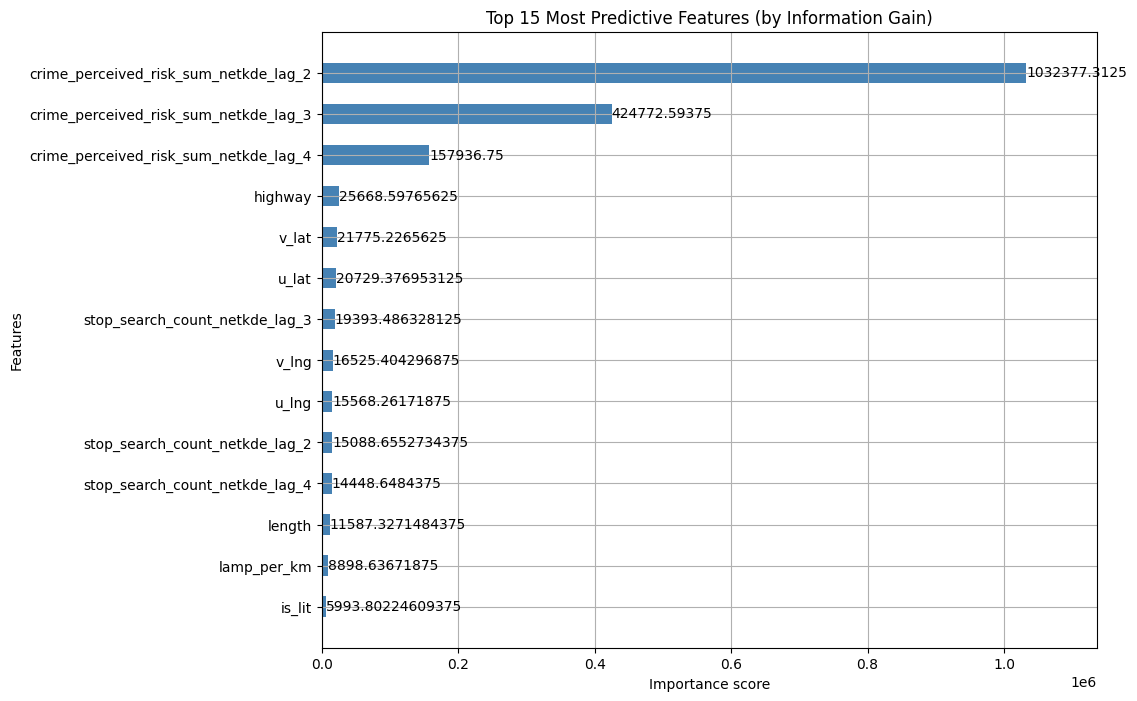


Feature Importance Rankings:
                                  Feature          Gain
0   crime_perceived_risk_sum_netkde_lag_2  1.032377e+06
1   crime_perceived_risk_sum_netkde_lag_3  4.247726e+05
2   crime_perceived_risk_sum_netkde_lag_4  1.579368e+05
3                                 highway  2.566860e+04
4                                   v_lat  2.177523e+04
5                                   u_lat  2.072938e+04
6          stop_search_count_netkde_lag_3  1.939349e+04
7                                   v_lng  1.652540e+04
8                                   u_lng  1.556826e+04
9          stop_search_count_netkde_lag_2  1.508866e+04
10         stop_search_count_netkde_lag_4  1.444865e+04
11                                 length  1.158733e+04
12                            lamp_per_km  8.898637e+03
13                                 is_lit  5.993802e+03


,Feature,Gain
0,crime_perceived_risk_sum_netkde_lag_2,1.032377e+06
1,crime_perceived_risk_sum_netkde_lag_3,4.247726e+05
2,crime_perceived_risk_sum_netkde_lag_4,1.579368e+05
3,highway,2.566860e+04
4,v_lat,2.177523e+04
5,u_lat,2.072938e+04
6,stop_search_count_netkde_lag_3,1.939349e+04
7,v_lng,1.652540e+04
8,u_lng,1.556826e+04
9,stop_search_count_netkde_lag_2,1.508866e+04


In [15]:
feature_importance(model, X_train)

In [16]:
future_edges, future_node = predict_and_map_to_nodes(
    df_ml, 
    model, 
    X_train, 
    month_t_minus_2='2026_05', 
    month_t_minus_3='2026_04', 
    month_t_minus_4='2026_03'
)

Predicting future safety scores...


In [18]:
osm_tag_mapping(future_edges)

Saved OSM Tag mapping. Use this to tag your .osm.pbf file.


In [23]:
simulation_results = evaluate_routing_performance(future_edges, num_simulations=1000)

simulation_results.head()

Building evaluation graph...
Running 1000 simulated Origin-Destination pairs...


Simulating Routes: 100%|██████████| 1000/1000 [00:16<00:00, 61.22it/s]


=== Route Evaluation Results ===
Total valid divergent routes simulated: 969
Average Distance Increase: 6.89%
Average Risk Reduction: 82.65%
Average Safety Improvement Efficiency (SIE): 81.2480 risk units/metre


,dist_shortest,dist_safest,risk_shortest,risk_safest,pct_risk_reduction,pct_distance_increase,sie
0,3023.720156,3135.999170,6181.518680,272.240433,95.595897,3.713274,52.630300
1,4055.318312,4492.291260,49230.664283,722.463366,98.532493,10.775306,111.009620
2,7413.970009,8023.572129,16771.738548,2202.819254,86.865886,8.222344,23.899063
3,2124.510324,2206.809497,7144.180676,532.360656,92.548332,3.873795,80.338839
4,4705.904814,5094.579792,57248.854699,2787.493439,95.130918,8.259304,140.120575
